# V23: Portfolio Strategy Comparison - Threshold Optimization

This notebook focuses on optimizing the **AI Decision Threshold** to improve the **Precision (TP/FP ratio)**. 
Instead of using a fixed 0.5 threshold, we find the optimal point using the **F0.5-Score**, which prioritizes Precision over Recall.

### Models in this Comparison:
1. **Markowitz Only**: Standard Mean-Variance Optimization (Baseline).
2. **RF + Graph (Opt Threshold)**: RF gating with optimized threshold + MIS Selection.
3. **XGB + Graph (Opt Threshold)**: XGBoost gating with optimized threshold + MIS Selection.
4. **RF + Graph (Fixed 0.5)**: Standard RF gating for comparison.
5. **BTC Benchmark**: Buy and Hold Bitcoin.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'dataset_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = '../dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 990 rows


In [2]:
# --- 2. Threshold Optimization Function ---

def find_optimal_threshold(model, X, y, beta=0.5):
    """
    Finds the threshold that maximizes the F-beta score.
    Beta = 0.5 gives more weight to Precision (minimizing False Positives).
    """
    probs = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.3, 0.8, 51)
    scores = [fbeta_score(y, (probs >= t).astype(int), beta=beta) for t in thresholds]
    
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]

# --- 3. Model Training ---
print("Training AI Gatekeepers with Threshold Optimization...")

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_opt_t, rf_score = find_optimal_threshold(rf_model, X_train, y_train)
rf_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

# 2. XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_opt_t, xgb_score = find_optimal_threshold(xgb_model, X_train, y_train)
xgb_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimal Threshold RF: {rf_opt_t:.2f} (F0.5-Score: {rf_score:.2f})")
print(f"Optimal Threshold XGB: {xgb_opt_t:.2f} (F0.5-Score: {xgb_score:.2f})")
print("✓ Training Complete.")

Training AI Gatekeepers with Threshold Optimization...
Optimal Threshold RF: 0.37 (F0.5-Score: 1.00)
Optimal Threshold XGB: 0.60 (F0.5-Score: 0.87)
✓ Training Complete.


In [3]:
# --- 4. Strategy Logic ---

def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    def neg_sharpe(weights):
        port_ret = np.sum(weights * mu)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_ret / port_vol if port_vol > 0.0001 else 0
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    guess = [1. / len(mu)] * len(mu)
    try:
        res = minimize(neg_sharpe, guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_returns.columns, res.x)) if res.success else dict(zip(selected_returns.columns, guess))
    except:
        return dict(zip(selected_returns.columns, guess))

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, lookback=30, cor_t=0.5):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    weights_log = []
    
    for i, date in enumerate(test_dates[:-1]):
        # Gate Logic
        if strategy_type == 'Markowitz Only':
            is_risk_off = False
        else:
            # Risk-Off if Probability of Bull is lower than optimized threshold
            is_risk_off = ai_probs.loc[date] < threshold
        
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        if is_risk_off:
            weights = {'CASH': 1.0}
        else:
            if 'Graph' in strategy_type:
                selected = get_mis_assets(window_rets, correlation_threshold=cor_t)
                weights = optimize_markowitz(window_rets[selected])
            else:
                weights = optimize_markowitz(window_rets)
        
        weights_log.append(weights)
        next_date = test_dates[i+1]
        next_rets = returns.loc[next_date]
        day_ret = 0 if 'CASH' in weights else sum(w * next_rets[a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), weights_log

In [4]:
# --- 5. Backtest Execution ---
test_dates = rf_probs.index
results = {}

sim_configs = [
    ('Markowitz Only', 'Markowitz Only', None, 0.5),
    ('RF+Graph Opt', 'RF + Graph (Opt Threshold)', rf_probs, rf_opt_t),
    ('XGB+Graph Opt', 'XGB + Graph (Opt Threshold)', xgb_probs, xgb_opt_t),
    ('RF+Graph Fix', 'RF + Graph (Fixed 0.5)', rf_probs, 0.5),
    ('XGB+Graph Fix', 'XGB + Graph (Fixed 0.5)', xgb_probs, 0.5)
]

for s_key, label, probs, t_val in sim_configs:
    print(f"Running sim: {label} with Threshold: {t_val:.2f}...")
    df, _ = run_simulation(s_key, test_dates, returns, probs, threshold=t_val)
    results[label] = df

# BTC Benchmark
btc = data.loc[test_dates, 'BTC-USD']
results['Buy and Hold (BTC)'] = pd.DataFrame({'Portfolio_Value': (btc / btc.iloc[0] * 100)}, index=test_dates)

print("✓ Backtests Finished.")

Running sim: Markowitz Only with Threshold: 0.50...
Running sim: RF + Graph (Opt Threshold) with Threshold: 0.37...
Running sim: XGB + Graph (Opt Threshold) with Threshold: 0.60...
Running sim: RF + Graph (Fixed 0.5) with Threshold: 0.50...
Running sim: XGB + Graph (Fixed 0.5) with Threshold: 0.50...
✓ Backtests Finished.


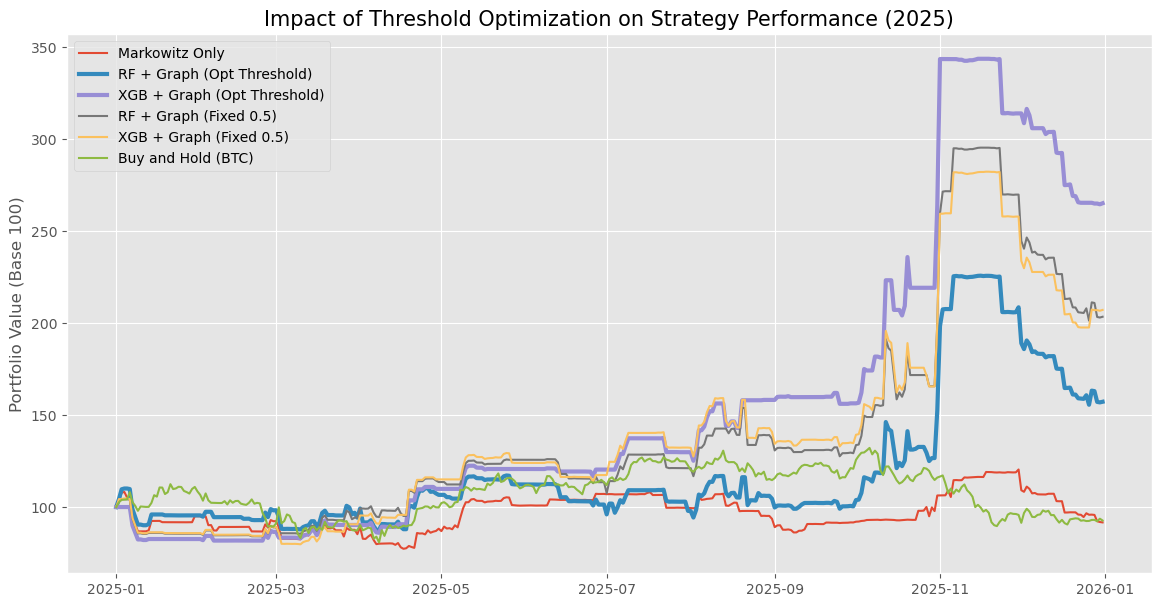

In [5]:
# --- 6. Visualization ---
plt.figure(figsize=(14, 7))
for label, df in results.items():
    lw = 3 if "Opt" in label else 1.5
    plt.plot(df.index, df['Portfolio_Value'], label=label, linewidth=lw)

plt.title("Impact of Threshold Optimization on Strategy Performance (2025)", fontsize=15)
plt.ylabel("Portfolio Value (Base 100)")
plt.legend()
plt.grid(True)
plt.savefig('v23_threshold_optimization_comparison.png', dpi=300)
plt.show()

In [6]:
# --- 7. Metrics Summary ---
summary = []
for label, df in results.items():
    ret = df['Portfolio_Value'].pct_change().dropna()
    total_return = (df['Portfolio_Value'].iloc[-1] / 100) - 1
    sharpe = (ret.mean() * 252) / (ret.std() * np.sqrt(252))
    summary.append({'Strategy': label, 'Total Return': f"{total_return:.2%}", 'Sharpe Ratio': round(sharpe, 2)})

print(pd.DataFrame(summary))

                      Strategy Total Return  Sharpe Ratio
0               Markowitz Only       -8.35%         -0.02
1   RF + Graph (Opt Threshold)       57.21%          0.83
2  XGB + Graph (Opt Threshold)      165.07%          1.62
3       RF + Graph (Fixed 0.5)      103.40%          1.17
4      XGB + Graph (Fixed 0.5)      107.11%          1.19
5           Buy and Hold (BTC)       -7.32%          0.02
